## Pendulum
Philipp Schlatter, LSTM FAU (2026)

Part of PSD Lecture

Binder: https://mybinder.org/v2/gh/pschlatt1/notebooks/PSD/main?filepath=pendulum.ipynb

Colab: https://colab.research.google.com/github/pschlatt1/notebooks/blob/main/PSD/pendulum.ipynb

<a target="_blank" href="https://colab.research.google.com/github/pschlatt1/notebooks/blob/main/PSD/pendulum.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
  # for Google Colab and interative figures
  # !pip install -q ipympl
  # get_ipython().kernel.do_shutdown(restart=True)
  from google.colab import output
  output.enable_custom_widget_manager()

In [2]:
%matplotlib widget
#%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [4]:
# Model definitions
def model(y, t, omega, zeta):
    theta, theta_dot = y
    dydt = [theta_dot, -2*zeta*omega*theta_dot - omega**2 * np.sin(theta)]
    return dydt

def model_lin(y, t, omega, zeta):
    theta, theta_dot = y
    dydt = [theta_dot, -2*zeta*omega*theta_dot - omega**2 * theta]
    return dydt

In [5]:
# Parameters
omega = 6.0
zeta = 0.

# Time vector
t = np.linspace(0, 5, 1001)

# Initial condition: y0 = [theta(0), theta_dot(0)]
y0 = [0, 12]

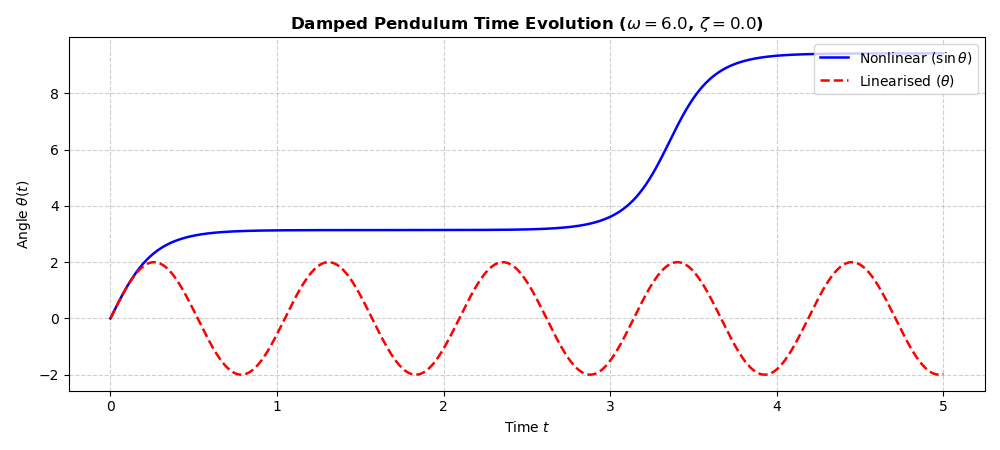

In [7]:
# Comparison linear and non-linear model

sol = odeint(model, y0, t, args=(omega, zeta))
sol_lin = odeint(model_lin, y0, t, args=(omega, zeta))

plt.figure(figsize=(10, 4.5))
plt.plot(t, sol[:, 0], 'b-', label=r'Nonlinear ($\sin\theta$)', linewidth=1.8)
plt.plot(t, sol_lin[:, 0], 'r--', label=r'Linearised ($\theta$)', linewidth=1.8)
plt.title(rf'Damped Pendulum Time Evolution ($\omega = {omega}$, $\zeta = {zeta}$)', fontsize=12, fontweight='bold')
plt.xlabel(r'Time $t$')
plt.ylabel(r'Angle $\theta(t)$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

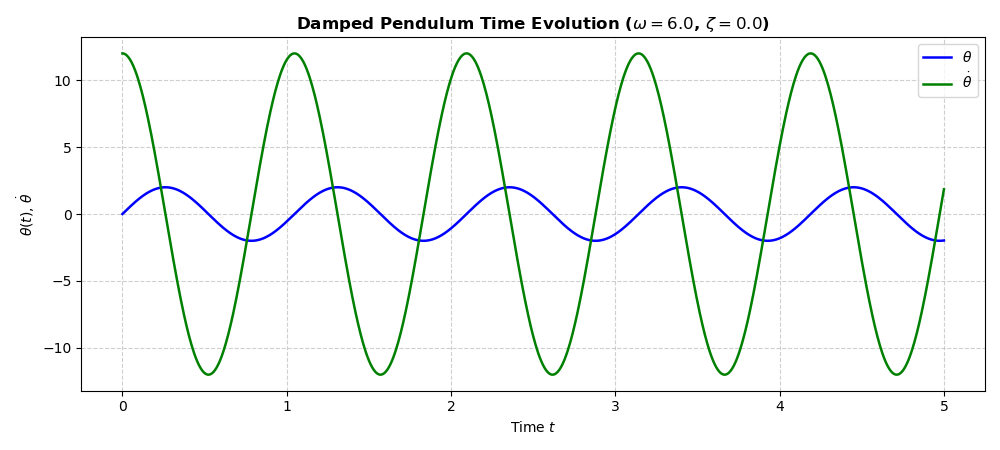

In [8]:
plt.figure(figsize=(10, 4.5))
plt.plot(t, sol_lin[:, 0], 'b-', label=r'$\theta$', linewidth=1.8)
plt.plot(t, sol_lin[:, 1], 'g-', label=r'$\dot{\theta}$', linewidth=1.8)
plt.title(rf'Damped Pendulum Time Evolution ($\omega = {omega}$, $\zeta = {zeta}$)', fontsize=12, fontweight='bold')
plt.xlabel(r'Time $t$')
plt.ylabel(r'$\theta(t)$, $\dot{\theta}$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

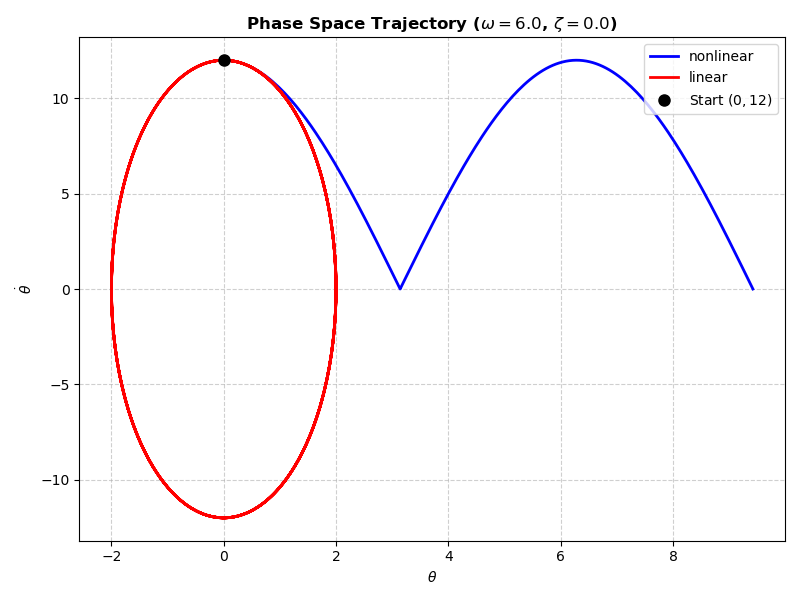

In [9]:
# Phase Space
plt.figure(figsize=(8, 6))
plt.plot(sol[:, 0], sol[:, 1], 'b-', linewidth=2, label=r'nonlinear')
plt.plot(sol_lin[:, 0], sol_lin[:, 1], 'r-', linewidth=2, label=r'linear')
plt.plot(y0[0], y0[1], 'ko', markersize=8, label=rf'Start $({y0[0]}, {y0[1]})$')

plt.title(rf'Phase Space Trajectory ($\omega = {omega}$, $\zeta = {zeta}$)', fontsize=12, fontweight='bold')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\dot{\theta}$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()